I0000 00:00:1778433381.344570    5485 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778433386.070256    5485 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778433395.139979    5485 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 30s 3us/step


/home/micheal/ml_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778433440.246603    5485 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1778433442.741021    5485 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7230 - loss: 0.8491

W0000 00:00:1778433574.036931    5485 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 138s 282ms/step - accuracy: 0.8574 - loss: 0.4539 - val_accuracy: 0.9699 - val_loss: 0.1009
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 97s 260ms/step - accuracy: 0.9607 - loss: 0.1369 - val_accuracy: 0.9830 - val_loss: 0.0584
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 196ms/step - accuracy: 0.9727 - loss: 0.0955 - val_accuracy: 0.9822 - val_loss: 0.0594
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 66s 175ms/step - accuracy: 0.9792 - loss: 0.0754 - val_accuracy: 0.9862 - val_loss: 0.0443
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - accuracy: 0.9810 - loss: 0.0654 - val_accuracy: 0.9888 - val_loss: 0.0397


W0000 00:00:1778433920.577177    5485 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.



Test Accuracy: 0.9895


W0000 00:00:1778433926.414661    5485 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


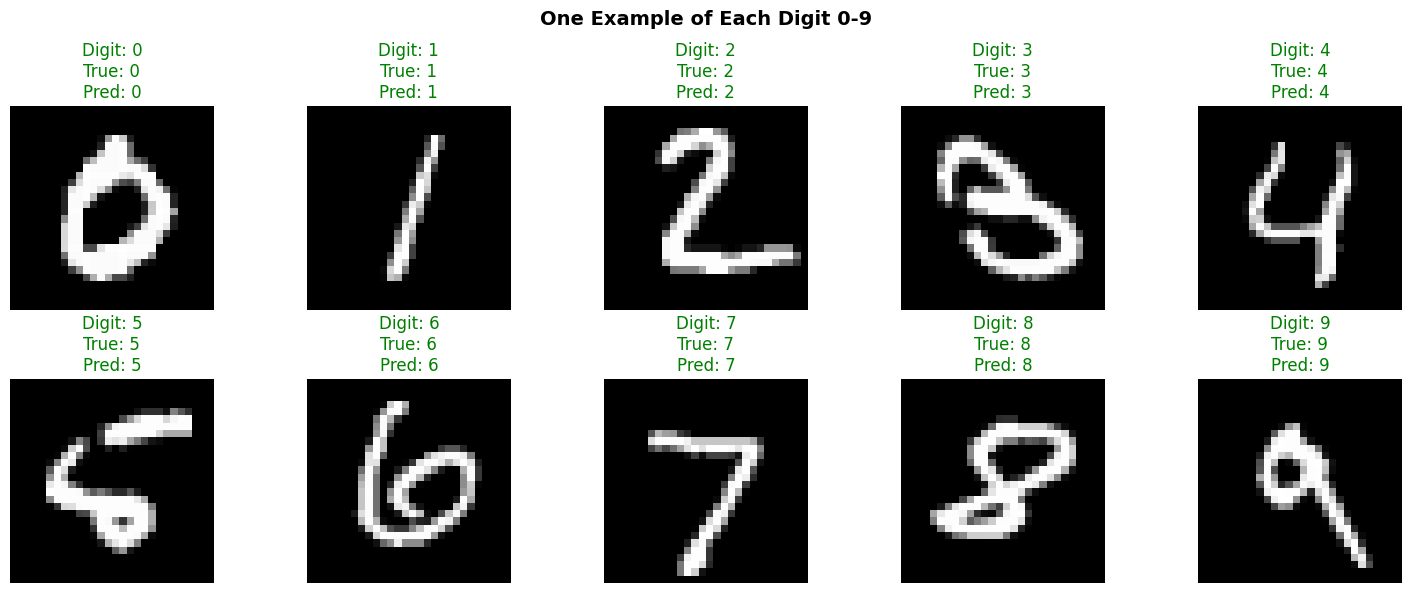

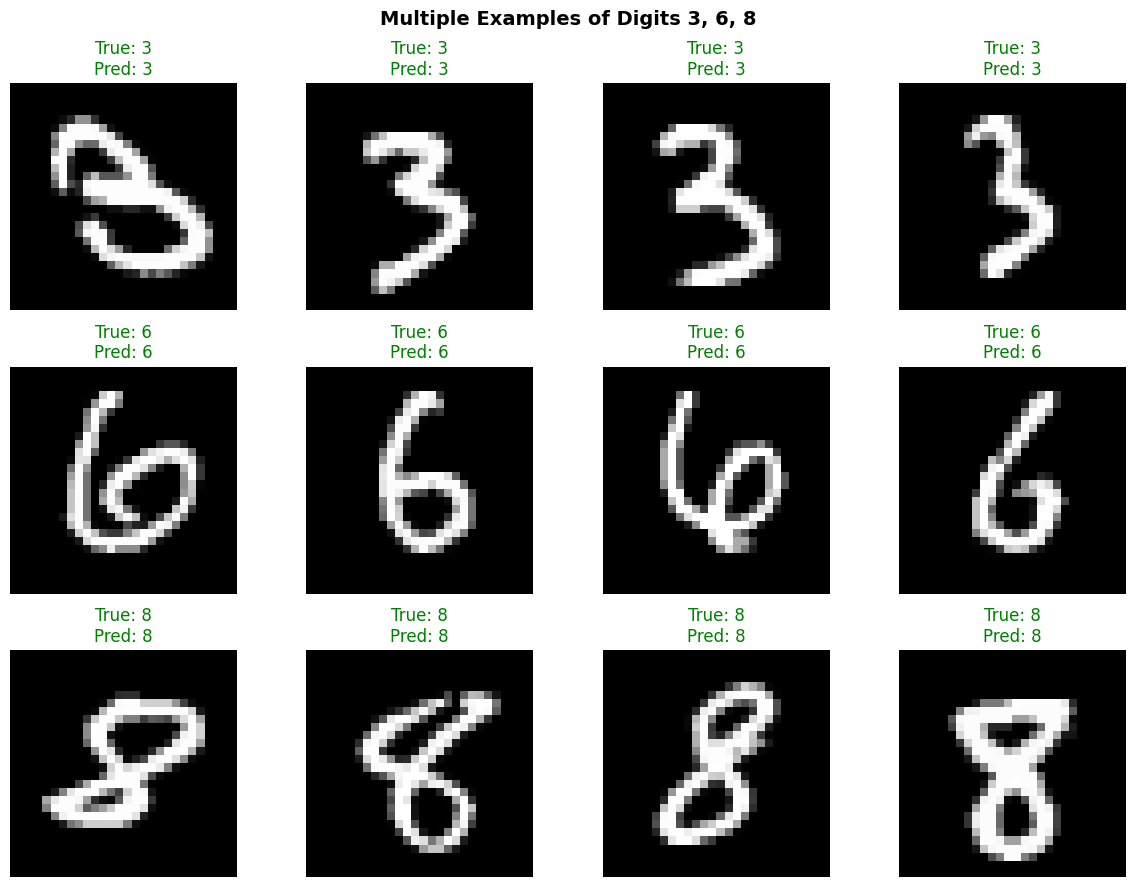

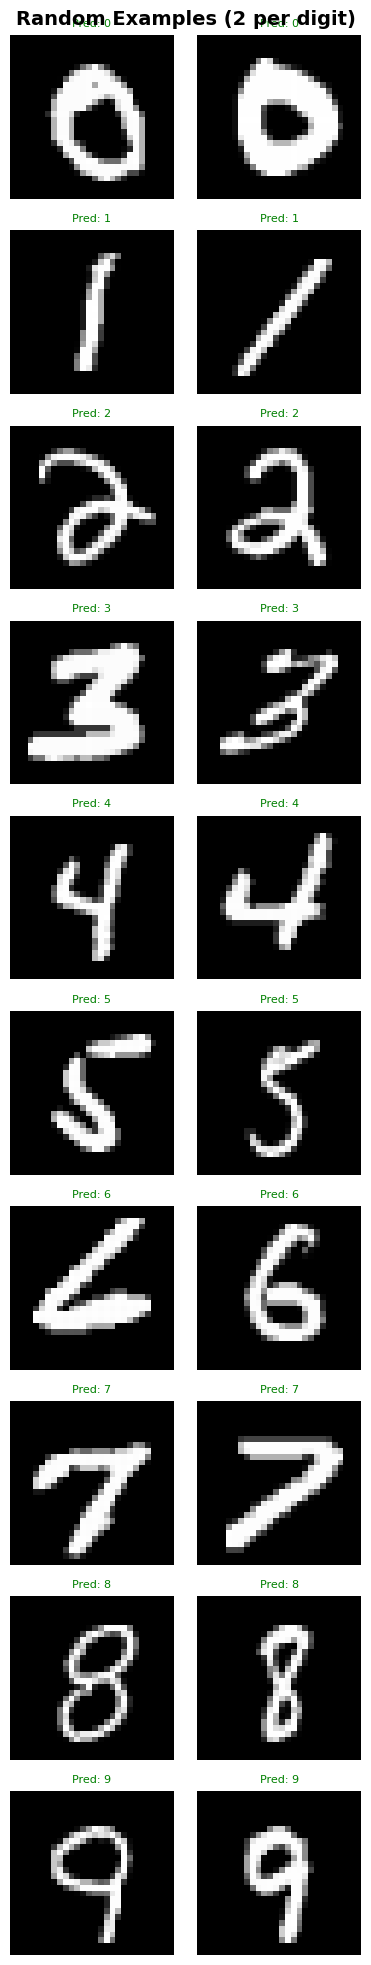


======= CLASSIFICATION REPORT =======

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



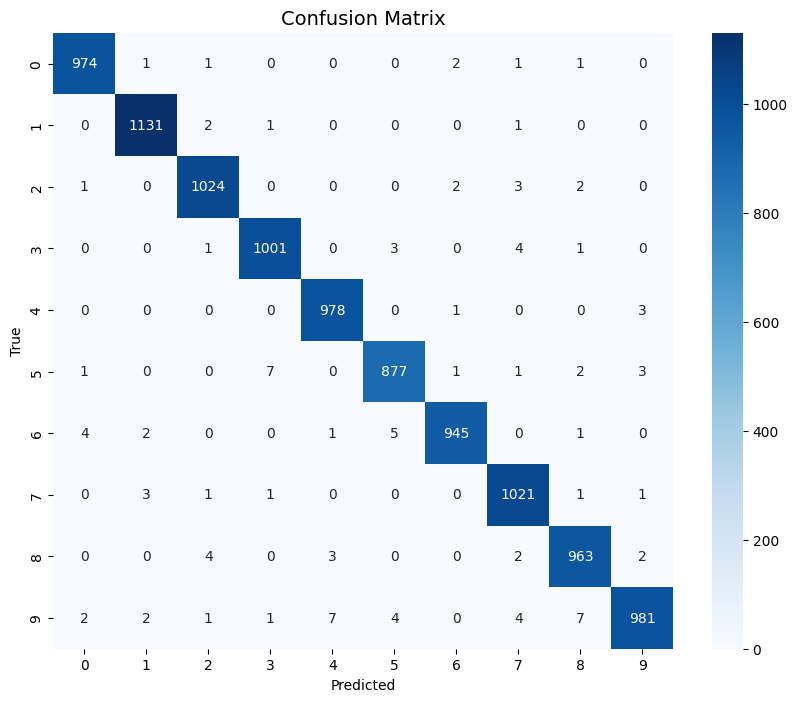


======= CONFUSIONS FOR DIGITS 3, 6, 8 =======

Digit 3: 99.1% correct
  → Misclassified as 2: 1 times
  → Misclassified as 5: 3 times
  → Misclassified as 7: 4 times
  → Misclassified as 8: 1 times

Digit 6: 98.6% correct
  → Misclassified as 0: 4 times
  → Misclassified as 1: 2 times
  → Misclassified as 4: 1 times
  → Misclassified as 5: 5 times
  → Misclassified as 8: 1 times

Digit 8: 98.9% correct
  → Misclassified as 2: 4 times
  → Misclassified as 4: 3 times
  → Misclassified as 7: 2 times
  → Misclassified as 9: 2 times


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load and preprocess
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Build CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"\nTest Accuracy: {test_acc:.4f}")

# Predict
y_pred_classes = np.argmax(model.predict(x_test), axis=1)

# Show one example of each digit
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for digit in range(10):
    idx = np.where(y_test == digit)[0][0]

    axes.flat[digit].imshow(
        x_test[idx].reshape(28, 28),
        cmap='gray'
    )

    color = 'green' if y_test[idx] == y_pred_classes[idx] else 'red'

    axes.flat[digit].set_title(
        f'Digit: {digit}\nTrue: {y_test[idx]}\nPred: {y_pred_classes[idx]}',
        color=color
    )

    axes.flat[digit].axis('off')

plt.suptitle(
    'One Example of Each Digit 0-9',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Show examples of digits 3, 6, 8
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for row, digit in enumerate([3, 6, 8]):

    indices = np.where(y_test == digit)[0][:4]

    for col, idx in enumerate(indices):

        axes[row, col].imshow(
            x_test[idx].reshape(28, 28),
            cmap='gray'
        )

        color = 'green' if digit == y_pred_classes[idx] else 'red'

        axes[row, col].set_title(
            f'True: {digit}\nPred: {y_pred_classes[idx]}',
            color=color
        )

        axes[row, col].axis('off')

plt.suptitle(
    'Multiple Examples of Digits 3, 6, 8',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Random examples
fig, axes = plt.subplots(10, 2, figsize=(4, 20))

for digit in range(10):

    selected = np.random.choice(
        np.where(y_test == digit)[0],
        2,
        replace=False
    )

    for col, idx in enumerate(selected):

        axes[digit, col].imshow(
            x_test[idx].reshape(28, 28),
            cmap='gray'
        )

        color = 'green' if digit == y_pred_classes[idx] else 'red'

        axes[digit, col].set_title(
            f'Pred: {y_pred_classes[idx]}',
            color=color,
            fontsize=8
        )

        axes[digit, col].axis('off')

    axes[digit, 0].set_ylabel(
        f'Digit {digit}',
        rotation=0,
        size=12,
        labelpad=20
    )

plt.suptitle(
    'Random Examples (2 per digit)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Classification report
print("\n======= CLASSIFICATION REPORT =======\n")

print(classification_report(y_test, y_pred_classes))

# Confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    confusion_matrix(y_test, y_pred_classes),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix', fontsize=14)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

# Confusions for digits 3, 6, 8
print("\n======= CONFUSIONS FOR DIGITS 3, 6, 8 =======")

for digit in [3, 6, 8]:

    preds = y_pred_classes[y_test == digit]

    print(f"\nDigit {digit}: {np.mean(preds == digit) * 100:.1f}% correct")

    for wrong_digit in np.unique(preds[preds != digit]):

        print(
            f"  → Misclassified as {wrong_digit}: "
            f"{np.sum(preds == wrong_digit)} times"
        )